In [1]:
# @title Run this first — works on Google Colab and locally { display-mode: "form" }
# On Colab: clones the repo and installs all packages (~10 min on first run).
# Locally:  just verifies imports (assumes you already ran bash setup_env.sh).
import sys, os


IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # ── NumPy 2.x compatibility shim ──────────────────────────────────────────────
    # NumPy 2.0 removed several type aliases and moved some exceptions to
    # np.exceptions.  allensdk and its deps (xarray, etc.) still reference the old
    # names.  All restorations are exact same-value aliases -- no behavior changes.
    import numpy as _np

    # Type aliases removed in NumPy 2.0
    if not hasattr(_np, 'unicode_'):
        _np.unicode_ = _np.str_      # used by old xarray (dtypes.py)
    if not hasattr(_np, 'string_'):
        _np.string_ = _np.bytes_     # used by some h5py / allensdk paths

    # Exception classes moved from np.<Name> to np.exceptions.<Name> in NumPy 2.0
    if hasattr(_np, 'exceptions'):
        for _name in ('VisibleDeprecationWarning', 'ComplexWarning',
                    'ModuleDeprecationWarning'):
            if not hasattr(_np, _name):
                _val = getattr(_np.exceptions, _name, None)
                if _val is not None:
                    setattr(_np, _name, _val)
        del _name, _val

    del _np
    # ──────────────────────────────────────────────────────────────────────────────
    # TODO: replace with your actual public GitHub repo URL before sharing.
    REPO = "https://github.com/NeoNeuron/ccnss26-tutorials"
    REPO_DIR = "/content/ccnss26-tutorials"

    if not os.path.exists(REPO_DIR):
        print("Cloning repo...")
        ret = os.system(f"git clone --quiet {REPO} {REPO_DIR}")
        if ret != 0:
            raise RuntimeError(f"git clone failed -- is REPO set correctly? {REPO!r}")
    sys.path.insert(0, REPO_DIR)

    def _pip(*args):
        cmd = f"{sys.executable} -m pip install -q " + " ".join(args)
        if os.system(cmd) != 0:
            raise RuntimeError(f"pip failed: {cmd}")

    try:
        # Fast path: packages already installed in this Colab session.
        import ssm  # noqa
        from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache  # noqa
    except (ImportError, AttributeError):
        print("Installing packages (~10 min)...")
        # Cython must be present before ssm's C extensions are compiled.
        _pip("Cython", "setuptools")
        _pip("--no-build-isolation",
             "'ssm @ git+https://github.com/lindermanlab/ssm.git@master'")
        _pip("scipy", "matplotlib", "pandas", "scikit-learn", "networkx", "pynwb", "dandi")
        # allensdk declares numpy<1.24 / pandas==1.5.3 / scipy<1.11 -- these have no
        # pre-built wheels on modern hardware.  Install --no-deps to bypass the
        # resolver, then add allensdk's actual runtime dependencies individually.
        _pip("allensdk", "--no-deps")
        _pip("SimpleITK", "xarray", "simplejson", "nest-asyncio",
             "psycopg2-binary", "pynrrd", "future", "requests-toolbelt",
             "scikit-image", "statsmodels", "seaborn", "'marshmallow<4.0.0'",
             "argschema", "boto3", "semver", "cachetools", "sqlalchemy")
        _pip("nlb-tools", "--no-deps")
        _pip("-e", f"{REPO_DIR}/neural-data-analysis/")
        print("Done.")

# ── smoke test ────────────────────────────────────────────────────────────────
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache  # noqa
import ssm  # noqa
print("✅ Setup complete.")

/Users/kchen/Workspace/ccnss26-tutorials/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete.


# CCNSS 2026 — Session 2: Dynamics and States

**Theme:** From population activity to dynamics and discrete states.

Three modules on the NLB MC_Maze dataset:
- **2A** — PCA on population activity
- **2B** — Linear Dynamical Systems (`ssm`)
- **2C** — Hidden Markov Models (`ssm`)
- **Wrap-up** — Where the field is going (LFADS, CEBRA, MARBLE)

In [2]:
# @title Setup (run once)
import sys
import numpy as np, matplotlib.pyplot as plt
from ccnss_helpers import data, plotting, save_checkpoint, load_or_compute
print("✅ Setup complete.")

✅ Setup complete.


In [3]:
mm = data.load_mc_maze_small(cache_dir="data")
binned_wide = mm["binned_spikes"]    # (trials, bins, neurons) — wide window, aligned to movement onset
bin_times   = mm["bin_times"]        # bin-centre times relative to movement onset (s)
directions  = mm["trial_directions"] # reach condition (trial_type); single-target, no-barrier reaches only
hand_wide   = mm["hand_trajectory"]  # (trials, bins, 2) hand xy
bin_size    = mm["bin_size_s"]       # seconds
trial_info  = mm["trial_info"]       # per-trial event times: target_on / go_cue / move_onset, rt, delay

# The loader keeps only trial_version == 0 (single target, no barrier) and bins a
# wide window so the full task sequence is visible in a PSTH. For the population
# analyses below we slice the NLB-canonical peri-movement window [-750, +450] ms.
peri = (bin_times >= -1.00) & (bin_times < 0.20)
binned = binned_wide[:, peri, :]     # (trials, n_bins, neurons)
hand   = hand_wide[:, peri, :]
print("single-target trials (wide):", binned_wide.shape, "| peri-movement:", binned.shape)
print("reach conditions:", np.unique(directions))

single-target trials (wide): (32, 340, 107) | peri-movement: (32, 240, 107)
reach conditions: [ 2  3  4  6  7  8 10 11 12]


In [4]:
trial_info

,trial_type,target_on_time,go_cue_time,move_onset_time,rt,delay,target_on_rel,go_cue_rel
0,12,4.176,4.324,4.580,256,148,-0.404,-0.256
1,7,21.399,22.263,22.559,296,864,-1.160,-0.296
2,8,33.908,34.873,35.181,308,965,-1.273,-0.308
3,7,37.062,37.910,38.240,330,848,-1.178,-0.330
4,2,42.508,43.340,43.630,290,832,-1.122,-0.290
5,4,48.699,49.197,49.502,305,498,-0.803,-0.305
6,7,57.850,58.632,58.931,299,782,-1.081,-0.299
7,6,67.294,67.959,68.202,243,665,-0.908,-0.243
8,3,72.983,73.164,73.456,292,181,-0.473,-0.292
9,4,110.481,111.029,111.333,304,548,-0.852,-0.304


Text(0.5, 1.0, 'Trial 0 raster (first 100 neurons)')

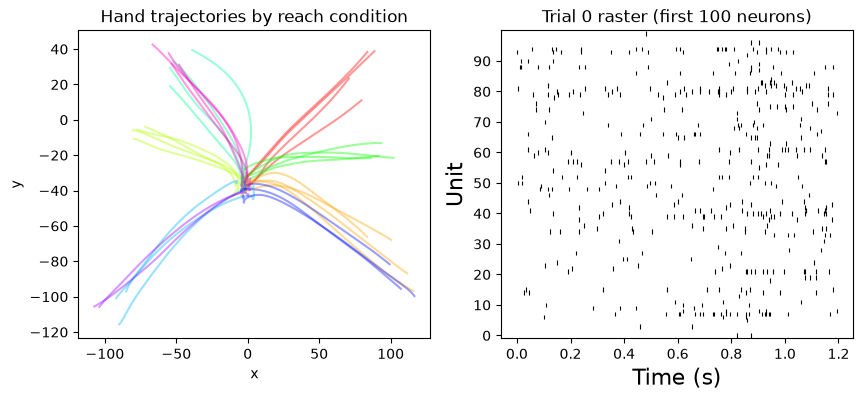

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
uniq = np.unique(directions)
for d in uniq:
    m = directions == d
    c_id = np.where(uniq == d)[0][0]
    ax[0].plot(hand[m, :, 0].T, hand[m, :, 1].T, color=plt.cm.hsv(c_id / len(uniq)), alpha=0.4)
ax[0].set_title("Hand trajectories by reach condition")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
# Raster of one trial (peri-movement window).
n_show = min(100, binned.shape[2])
trial0_spikes = {n: np.where(binned[0, :, n] > 0)[0] * bin_size for n in range(n_show)}
plotting.plot_raster(trial0_spikes, ax=ax[1], eventplot_kwargs={"linelengths": 1.5})
ax[1].set_yticks(np.arange(0, n_show, 10))
ax[1].set_ylim(-1, n_show)
ax[1].set_title(f"Trial 0 raster (first {n_show} neurons)")

### Population PSTH and task structure

Each single-target trial runs **target on → (variable delay) → go cue → (reaction time) → movement onset**.
Below we average firing rate across all held-in neurons and trials over the wide window and mark the mean
event times (± std across trials) relative to movement onset. The `delay` and `rt` columns of `trial_info`
are exactly `go_cue − target_on` and `move_onset − go_cue` (in ms).

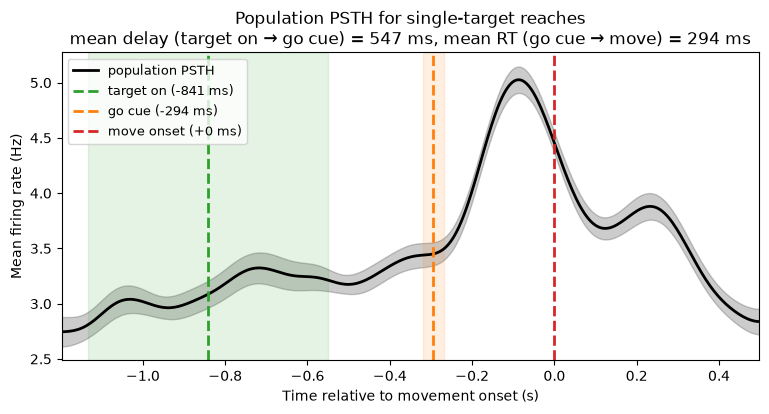

In [6]:
from scipy.ndimage import gaussian_filter1d

# Population PSTH over the wide window: mean firing rate per neuron (Hz), averaged
# across neurons and trials, then Gaussian-smoothed (50 ms). Aligned to movement onset.
rate_hz = binned_wide.sum(axis=2) / (binned_wide.shape[2] * bin_size)  # (trials, bins) mean Hz/neuron
rate_hz = gaussian_filter1d(rate_hz, sigma=0.050 / bin_size, axis=1)   # 50 ms smoothing
psth_mean = rate_hz.mean(axis=0)
psth_sem = rate_hz.std(axis=0) / np.sqrt(rate_hz.shape[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bin_times, psth_mean, color="k", lw=2, label="population PSTH")
ax.fill_between(bin_times, psth_mean - psth_sem, psth_mean + psth_sem, color="k", alpha=0.2)

# Mark the task events (mean ± std across trials, relative to movement onset).
events = [
    ("target on", trial_info["target_on_rel"].mean(), trial_info["target_on_rel"].std(), "tab:green"),
    ("go cue",    trial_info["go_cue_rel"].mean(),     trial_info["go_cue_rel"].std(),     "tab:orange"),
    ("move onset", 0.0,                                0.0,                                "tab:red"),
]
for name, mu, sd, c in events:
    ax.axvline(mu, color=c, lw=2, ls="--", label=f"{name} ({mu * 1000:+.0f} ms)")
    if sd > 0:
        ax.axvspan(mu - sd, mu + sd, color=c, alpha=0.12)

ax.set_xlim(bin_times[0], bin_times[-1])
ax.set_xlabel("Time relative to movement onset (s)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_title("Population PSTH for single-target reaches\n"
             f"mean delay (target on → go cue) = {trial_info['delay'].mean():.0f} ms, "
             f"mean RT (go cue → move) = {trial_info['rt'].mean():.0f} ms")
ax.legend(loc="upper left", fontsize=9);

## Module 2A — PCA on population activity

We trial-average per reach direction, stack as (conditions × time) × neurons, fit PCA,
and visualize the top 3 PC trajectories.

**Key idea:** if all neurons fired independently, you'd need N dimensions. The fact that
just 3 capture most of the variance means the population lives on a low-dimensional manifold.

In [7]:
def trial_average_per_direction(binned, dirs):
    """Returns (n_directions, n_bins, n_neurons) average rates."""
    unique_dirs = np.unique(dirs)
    return np.stack([binned[dirs == d].mean(axis=0) for d in unique_dirs])

avg = trial_average_per_direction(binned, directions)   # (n_directions, n_bins, n_neurons)
print(avg.shape)

(9, 240, 107)


In [8]:
# EXERCISE: fit PCA on the trial-averaged data and project to the top components
from sklearn.decomposition import PCA

n_directions, n_bins, n_neurons = avg.shape
# Firing rate (Hz) smoothed with a 50 ms Gaussian (the official MC_Maze
# convention). We smooth on the wide window *then* slice the peri-movement
# window so the kernel doesn't distort the trajectory at the window edges.
rates_wide = gaussian_filter1d(binned_wide / bin_size, sigma=0.050 / bin_size, axis=1)
avg_rates = trial_average_per_direction(rates_wide[:, peri, :], directions)
X = avg_rates.reshape(-1, n_neurons)  # (n_directions * n_bins, n_neurons)
pca = PCA(n_components=10).fit(X)
Z = pca.transform(X).reshape(n_directions, n_bins, 10)
print("Explained variance ratio (top 5):", pca.explained_variance_ratio_[:5])

Explained variance ratio (top 5): [0.21094112 0.11895154 0.11049533 0.06153896 0.03639754]


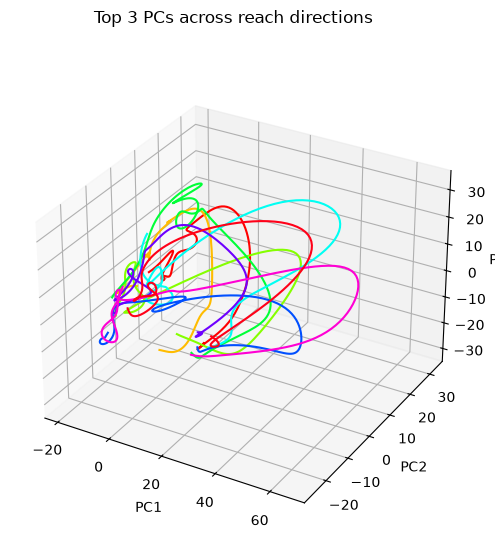

In [9]:
plotting.plot_latents_3d(Z[:, :, :3])
plt.suptitle("Top 3 PCs across reach directions");

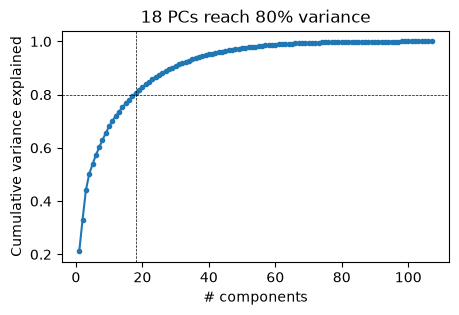

In [10]:
# EXERCISE: plot cumulative variance explained; how many PCs reach 80%?
# Fit the full PCA spectrum (top 10 only explains ~73%, so we need all components
# to honestly answer the 80% question).
full_pca = PCA().fit(X)
cum = np.cumsum(full_pca.explained_variance_ratio_)
k80 = int(np.argmax(cum >= 0.8)) + 1
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.arange(1, len(cum) + 1), cum, "o-", ms=3)
ax.axhline(0.8, color="k", lw=0.5, ls="--"); ax.axvline(k80, color="k", lw=0.5, ls="--")
ax.set_xlabel("# components"); ax.set_ylabel("Cumulative variance explained")
ax.set_title(f"{k80} PCs reach 80% variance");

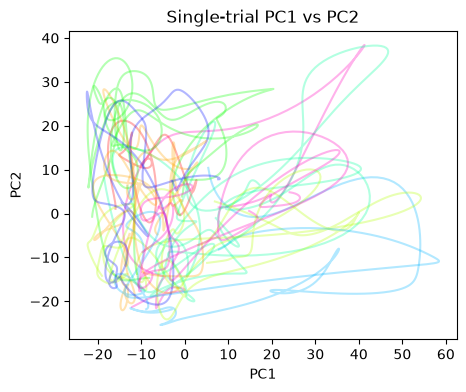

In [11]:
# CUTTABLE: project single trials into the trial-averaged PCA basis
single_rates = gaussian_filter1d(binned_wide / bin_size, sigma=0.050 / bin_size, axis=1)[:, peri, :]
Z_single = pca.transform(single_rates.reshape(-1, n_neurons)).reshape(binned.shape[0], n_bins, -1)
uniq = np.unique(directions)
fig, ax = plt.subplots(figsize=(5, 4))
for t in range(min(20, binned.shape[0])):
    c_id = np.where(uniq == directions[t])[0][0]
    ax.plot(Z_single[t, :, 0], Z_single[t, :, 1], alpha=0.3, color=plt.cm.hsv(c_id / len(uniq)))
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("Single-trial PC1 vs PC2");

In [12]:
save_checkpoint("module_2A", avg=avg, Z=Z, evr=pca.explained_variance_ratio_,
                components=pca.components_, mean=pca.mean_)
print("✅ 2A checkpoint saved.")

✅ 2A checkpoint saved.


## Module 2B — Linear Dynamical Systems

PCA gives us a low-D snapshot but ignores time. An LDS adds a transition model:

$$z_{t+1} = A z_t + \epsilon_t, \quad y_t = C z_t + \nu_t$$

We fit one with Linderman's `ssm` and compare latents to PCA. Then simulate from the fit.

> **Aside on GPFA:** structurally similar but puts a Gaussian Process prior on latents → smoother trajectories. Same conceptual goal; different smoothness regularizer.

In [13]:
# 2-minute tour of ssm: fit a tiny 2D LDS on toy data so the API is familiar.
import ssm
toy_T, toy_D, toy_N = 200, 2, 10
toy_lds = ssm.LDS(N=toy_N, D=toy_D, emissions="poisson")
toy_z, toy_y = toy_lds.sample(T=toy_T)
toy_fit = ssm.LDS(N=toy_N, D=toy_D, emissions="poisson")
toy_fit.fit(toy_y, num_iters=20, verbose=0)
print("Toy LDS fitted successfully. API: .sample(), .fit(), .most_likely_states() etc.")

Toy LDS fitted successfully. API: .sample(), .fit(), .most_likely_states() etc.


### The fitted parameters ("weights") and how they map to the equation

Recall the LDS

$$z_{t+1} = A\,z_t + \epsilon_t, \qquad y_t \sim \text{Poisson}\big(f(C\,z_t + d)\big)$$

A fitted `ssm.LDS` stores the learned matrices on two sub-objects — `.dynamics` (the latent transition) and `.emissions` (the latent → spikes map). The **weights** are exactly the matrices in the equation above:

| Symbol | Attribute | Shape | Meaning |
|---|---|---|---|
| $A$ | `lds.dynamics.A`  | `(D, D)` | **Transition matrix** — how the latent state propagates one bin forward, $z_{t+1}=A z_t$. Eigenvalues of $A$ set the timescales/oscillations of the dynamics. |
| $C$ | `lds.emissions.Cs` | `(1, N, D)` | **Loading / emission matrix** — maps the $D$ latent dims onto each of the $N$ neurons. Column $j$ is the population activity pattern that latent dim $j$ drives. (Stored with a leading axis of length $K$ = number of discrete states, here 1.) |
| $b$ | `lds.dynamics.bs` | `(1, D)` | Constant drift added to the latent update. |
| $d$ | `lds.emissions.ds` | `(1, N)` | Per-neuron baseline (sets each neuron's background log-rate). |
| $\epsilon_t$ | `lds.dynamics.Sigmas` | `(1, D, D)` | Covariance of the Gaussian **process noise** on the latent state. |

The shape symbols come from the constructor: `D` = latent dimension, `N` = number of neurons (observation dimension), `M` = input dimension (0 here), `K` = number of discrete states (1 for a plain LDS). `ssm` stores most weights with a leading axis of length `K` (one set per discrete state); `.A` is just a convenience property for `.As[0]`.

**The emission model depends on the `emissions=` argument** — the dynamics weights ($A,b,\epsilon$) are identical either way; only how $C z_t + d$ becomes $y_t$ changes:

- **`emissions="gaussian"`** — the textbook linear-Gaussian readout, exactly $y_t = C z_t + d + \nu_t$ with additive observation noise $\nu_t \sim \mathcal{N}(0, R)$. `ssm` uses a *diagonal* $R$ (independent per-neuron noise), stored as **per-neuron log-variances** in `lds.emissions.inv_etas` `(1, N)`; recover the variances with `np.exp(lds.emissions.inv_etas)`. Use for continuous observations (smoothed rates, LFP, calcium).

- **`emissions="poisson"`** (what we fit here) — $C z_t + d$ instead sets the **log firing rate** of each neuron (through a nonnegative link $f$) and spike counts are Poisson draws. The variability lives in the Poisson likelihood, so there is **no** additive Gaussian noise $\nu_t$ and **no** `inv_etas`. Use for spike counts.

The cell below prints $A$ for the generative model and the fitted model — close values mean `fit` recovered the true dynamics.

In [14]:
toy_lds.dynamics.A, toy_fit.dynamics.A

(array([[ 0.45152984,  0.66039443],
        [-0.66039443,  0.45152984]]),
 array([[ 0.7751276 , -0.52664839],
        [ 0.90883205,  0.19186925]]))

In [15]:
# EXERCISE: fit a D=6 LDS to single-trial spike counts
D_lat = 6
# ssm expects list of (T, N) arrays for trial-structured data
trials = [binned[i] for i in range(binned.shape[0])]
lds = ssm.LDS(N=binned.shape[2], D=D_lat, emissions="poisson")
elbos, q = lds.fit(trials, num_iters=30, verbose=0)
print("Final ELBO:", elbos[-1])

Final ELBO: -67602.47287409175


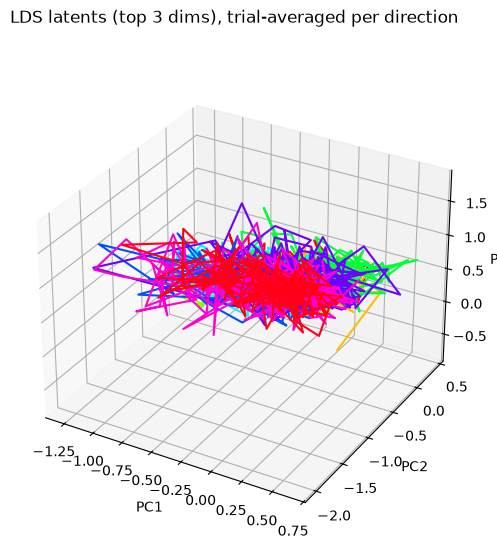

In [16]:
latents = np.stack(q.mean_continuous_states)  # (trials, bins, D)
avg_latents = trial_average_per_direction(latents, directions)   # (n_dir, bins, D)
plotting.plot_latents_3d(avg_latents[:, :, :3])
plt.suptitle("LDS latents (top 3 dims), trial-averaged per direction");

Text(0, 0.5, 'neuron')

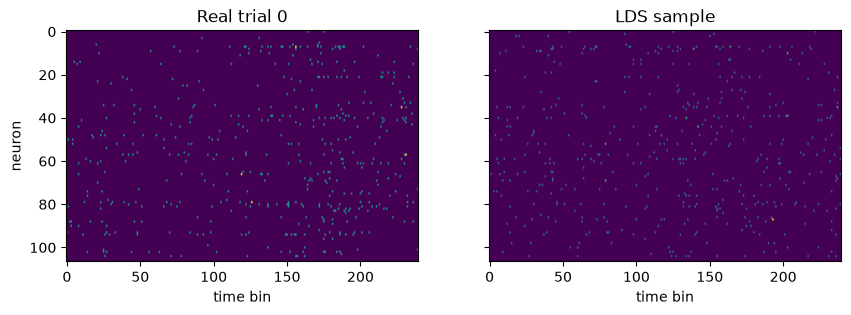

In [17]:
# EXERCISE: simulate from the fitted LDS and compare PSTH to the real data
sim_z, sim_y = lds.sample(T=binned.shape[1])
fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
ax[0].imshow(binned[0].T, aspect="auto")
ax[0].set_title("Real trial 0")
ax[1].imshow(sim_y.T, aspect="auto")
ax[1].set_title("LDS sample")
for a in ax: 
    a.set_xlabel("time bin")
ax[0].set_ylabel("neuron")

ELBO: -2032.6: 100%|██████████| 5/5 [00:00<00:00, 15.36it/s]


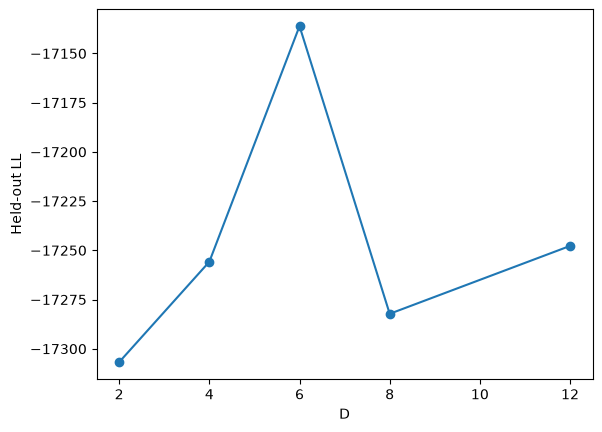

In [18]:
# CUTTABLE: vary D, plot held-out log-likelihood
n_train = int(0.75 * len(trials))
train, test = trials[:n_train], trials[n_train:]
lls = []
for D in [2, 4, 6, 8, 12]:
    m = ssm.LDS(N=binned.shape[2], D=D, emissions="poisson")
    m.fit(train, num_iters=15, verbose=0)  # returns (elbos, q) but we ignore
    lls.append(sum(m.approximate_posterior([t], num_iters=5)[0][-1] for t in test))
plt.plot([2, 4, 6, 8, 12], lls, "o-")
plt.xlabel("D")
plt.ylabel("Held-out LL");

In [19]:
save_checkpoint("module_2B", latents=latents, avg_latents=avg_latents)
print("✅ 2B checkpoint saved.")

✅ 2B checkpoint saved.


## Module 2C — Hidden Markov Models

Instead of continuous latents, we now ask: are there **discrete states** (e.g. baseline,
preparation, movement, hold)? Fit a Poisson-HMM with `ssm` and visualize the state sequence aligned to movement onset.

In [20]:
# EXERCISE: fit a 4-state Poisson HMM
K = 4
hmm = ssm.HMM(K=K, D=binned.shape[2], observations="poisson")
hmm.fit(trials, num_iters=40, verbose=0)
print("HMM fit complete.")

HMM fit complete.


Text(0.5, 1.0, 'Most-likely HMM state sequence (K=4)')

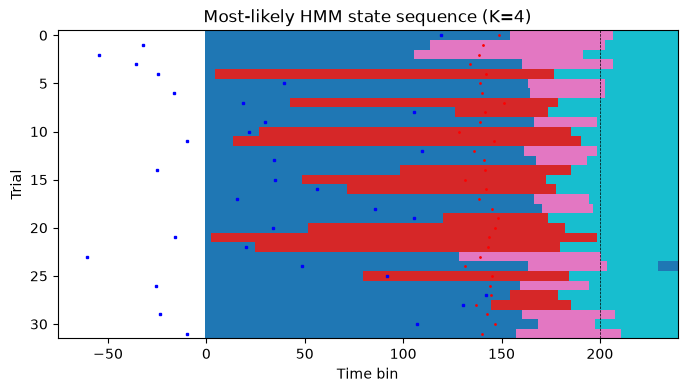

In [24]:
states = np.stack([hmm.most_likely_states(t) for t in trials])
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(states, aspect="auto", cmap="tab10", interpolation="nearest")
ax.axvline(1.00/bin_size, color="k", lw=0.5, ls="--")  # mark movement onset
for i in range(states.shape[0]):
    ax.plot((trial_info["go_cue_rel"][i] + 1.00) / bin_size, i, "r.", ms=2)  # mark movement onset
    ax.plot((trial_info["target_on_rel"][i] + 1.00) / bin_size, i, "bs", ms=2)  # mark movement onset
ax.set_xlabel("Time bin")
ax.set_ylabel("Trial")
ax.set_title(f"Most-likely HMM state sequence (K={K})")

In [25]:
# EXERCISE: refit with K=3 and K=6; interpret what the states correspond to
for K_try in [3, 6]:
    h = ssm.HMM(K=K_try, D=binned.shape[2], observations="poisson")
    h.fit(trials, num_iters=30, verbose=0)
    print(f"K={K_try}, mean dwell time per state:",
          [np.mean(np.diff(np.where(np.diff(h.most_likely_states(trials[0])) != 0)[0])) for _ in [0]])

/Users/kchen/Workspace/ccnss26-tutorials/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kchen/Workspace/ccnss26-tutorials/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


K=3, mean dwell time per state: [nan]
K=6, mean dwell time per state: [28.5]


In [26]:
# CUTTABLE: SLDS (Switching LDS) = 2B + 2C unified
slds = ssm.SLDS(N=binned.shape[2], K=4, D=6, emissions="poisson")
slds.fit(trials, num_iters=20, verbose=0)
print("SLDS fit complete — see ssm docs for posterior inference.")

SLDS fit complete — see ssm docs for posterior inference.


## Where the field is going

- **LFADS** — sequential VAE for neural dynamics. Pandarinath et al. 2018.
- **CEBRA** — contrastive embeddings constrained by behavior. Schneider et al. 2023.
- **MARBLE** — geometric/manifold methods for neural manifolds. Gosztolai et al. 2024.

Code-free — but worth bookmarking. See slide for paper + GitHub links.

In [27]:
# 🎉 End of Session 2
print("Session 2 complete! Resources and further reading in the slide deck.")

Session 2 complete! Resources and further reading in the slide deck.
